In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set()
import warnings 
warnings.filterwarnings('ignore')


In [2]:
cr=pd.read_csv("C:/Users/sweth/Downloads/Crop_recommendation.csv")

In [3]:
cr.head()

,Nitrogen,Phosphorous,Potassium,temperature,humidity,ph,rainfall,crop
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
cr.tail()

,Nitrogen,Phosphorous,Potassium,temperature,humidity,ph,rainfall,crop
2197,118.0,33.0,30.0,24.131797,67.225123,6.362608,173.322839,coffee
2198,117.0,32.0,34.0,26.272418,52.127394,6.758793,127.175293,coffee
2199,104.0,18.0,30.0,23.603016,60.396475,6.779833,140.937041,coffee
2200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2202 entries, 0 to 2201
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   float64
 1   Phosphorous  2200 non-null   float64
 2   Potassium    2200 non-null   float64
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   crop         2200 non-null   object 
dtypes: float64(7), object(1)
memory usage: 137.8+ KB


In [6]:
print("Columns:",cr.columns)

Columns: Index(['Nitrogen', 'Phosphorous', 'Potassium', 'temperature', 'humidity', 'ph',
       'rainfall', 'crop'],
      dtype='object')


In [7]:
print("Shape:",cr.shape)

Shape: (2202, 8)


In [8]:
cr.describe().T

,count,mean,std,min,25%,50%,75%,max
Nitrogen,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
Phosphorous,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
Potassium,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [9]:
cr.dtypes

Nitrogen       float64
Phosphorous    float64
Potassium      float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
crop            object
dtype: object

In [10]:
cr.isnull().sum()

Nitrogen       2
Phosphorous    2
Potassium      2
temperature    2
humidity       2
ph             2
rainfall       2
crop           2
dtype: int64

In [11]:
numerical_columns=['Nitrogen', 'Phosphorous', 'Potassium', 'temperature', 'humidity', 'ph',
       'rainfall']
for column in numerical_columns:
    cr[column]=cr[column].fillna(cr[column].median())


In [12]:
cr.isnull().sum()

Nitrogen       0
Phosphorous    0
Potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
crop           2
dtype: int64

In [13]:
categorical_columns=['crop']

for column in categorical_columns:
    cr[column]=cr[column].fillna(cr[column].mode()[0])


In [14]:
cr.isnull().sum()

Nitrogen       0
Phosphorous    0
Potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
crop           0
dtype: int64

In [15]:
numerical_columns = cr.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for column in numerical_columns:
    Q1 = cr[column].quantile(0.25)
    Q3 = cr[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cr[(cr[column] < lower) | (cr[column] > upper)]

    outlier_summary[column] = len(outliers)

outlier_summary

{'Nitrogen': 0,
 'Phosphorous': 138,
 'Potassium': 200,
 'temperature': 86,
 'humidity': 31,
 'ph': 57,
 'rainfall': 100}

In [16]:
columns = ['Phosphorous', 'Potassium', 'temperature', 'humidity', 'ph',
       'rainfall']  
for column in columns:
    Q1 = cr[column].quantile(0.25)
    Q3 = cr[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = cr[column].median()

    cr[column] = cr[column].apply(lambda x: median if x < lower or x > upper else x)
    

In [17]:
numerical_columns = cr.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for column in numerical_columns:
    Q1 = cr[column].quantile(0.25)
    Q3 = cr[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cr[(cr[column] < lower) | (cr[column] > upper)]

    outlier_summary[column] = len(outliers)

outlier_summary

{'Nitrogen': 0,
 'Phosphorous': 62,
 'Potassium': 48,
 'temperature': 15,
 'humidity': 41,
 'ph': 16,
 'rainfall': 79}

In [18]:
cr.shape


(2202, 8)

In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

cat_cols = ['crop']

for col in cat_cols:
    le = LabelEncoder()
    cr[col] = le.fit_transform(cr[col])
    label_encoders[col] = le

print("Encoding completed successfully!")

Encoding completed successfully!


In [20]:
#save the encoders
import joblib

joblib.dump(label_encoders, "label_encoders.pkl")

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [21]:
#verify they were saved
loaded_encoders = joblib.load("label_encoders.pkl")

print(loaded_encoders.keys())

dict_keys(['crop'])


In [22]:
cr.head()

,Nitrogen,Phosphorous,Potassium,temperature,humidity,ph,rainfall,crop
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,20
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,94.867624,20
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,94.867624,20
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,94.867624,20
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,94.867624,20


In [23]:
for col in cat_cols:
    print(f"\n{col}")

    counts = cr[col].value_counts().sort_index()

    if col == 'label':
        crop_names = label_encoder.inverse_transform(counts.index)

        result = pd.DataFrame({
            'Label': counts.index,
            'Crop': crop_names,
            'Count': counts.values
        })

        print(result)
    else:
        print(counts)


crop
crop
0     102
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
Name: count, dtype: int64


In [24]:
for col in cat_cols:
    print(f"\n{col}")

    counts = cr[col].value_counts().sort_index()

    crop_names = label_encoders[col].inverse_transform(counts.index)

    result = pd.DataFrame({
        'Encoded Value': counts.index,
        'Crop Name': crop_names,
        'Count': counts.values
    })

    print(result) 


crop
    Encoded Value    Crop Name  Count
0               0        apple    102
1               1       banana    100
2               2    blackgram    100
3               3     chickpea    100
4               4      coconut    100
5               5       coffee    100
6               6       cotton    100
7               7       grapes    100
8               8         jute    100
9               9  kidneybeans    100
10             10       lentil    100
11             11        maize    100
12             12        mango    100
13             13    mothbeans    100
14             14     mungbean    100
15             15    muskmelon    100
16             16       orange    100
17             17       papaya    100
18             18   pigeonpeas    100
19             19  pomegranate    100
20             20         rice    100
21             21   watermelon    100


In [25]:
cr.head()

,Nitrogen,Phosphorous,Potassium,temperature,humidity,ph,rainfall,crop
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,20
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,94.867624,20
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,94.867624,20
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,94.867624,20
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,94.867624,20


In [26]:
from sklearn.model_selection import train_test_split

X=cr.drop('crop',axis=1)
y=cr['crop'] 

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("Train Labels:", y_train.shape)
print("Test Labels:", y_test.shape)

Train Shape: (1761, 7)
Test Shape: (441, 7)
Train Labels: (1761,)
Test Labels: (441,)


In [27]:
#verify the class distribution
print("Training Set")
print(y_train.value_counts())

print("\nTesting Set")
print(y_test.value_counts())

Training Set
crop
0     81
7     80
4     80
12    80
17    80
8     80
20    80
11    80
18    80
21    80
2     80
16    80
19    80
5     80
15    80
10    80
1     80
6     80
14    80
13    80
9     80
3     80
Name: count, dtype: int64

Testing Set
crop
0     21
9     20
1     20
20    20
10    20
4     20
5     20
8     20
13    20
14    20
11    20
19    20
16    20
21    20
12    20
2     20
17    20
3     20
15    20
7     20
6     20
18    20
Name: count, dtype: int64


In [28]:
print("Before:", cr.shape)

new_born = cr.drop_duplicates()

print("After:", cr.shape) 

Before: (2202, 8)
After: (2202, 8)


In [29]:
from sklearn.preprocessing import StandardScaler
import joblib

# Initialize scaler 
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape)

Feature scaling completed successfully!
Training Shape: (1761, 7)
Testing Shape : (441, 7)


In [30]:
#Save and Verify Scaler

joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

loaded_scaler = joblib.load("scaler.pkl")
print(type(loaded_scaler)) 

Scaler saved successfully!
<class 'sklearn.preprocessing._data.StandardScaler'>


In [31]:
#SMOTE
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply only on training data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
) 

print("SMOTE applied successfully!")

print("\nBefore SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_resampled.value_counts()) 

SMOTE applied successfully!

Before SMOTE
crop
0     81
7     80
4     80
12    80
17    80
8     80
20    80
11    80
18    80
21    80
2     80
16    80
19    80
5     80
15    80
10    80
1     80
6     80
14    80
13    80
9     80
3     80
Name: count, dtype: int64

After SMOTE
crop
16    81
7     81
4     81
12    81
17    81
8     81
20    81
11    81
18    81
21    81
2     81
0     81
19    81
5     81
15    81
10    81
1     81
6     81
14    81
13    81
9     81
3     81
Name: count, dtype: int64


In [32]:
cr.shape

(2202, 8)

In [33]:
X_train_resampled
y_train_resampled
X_test_scaled
y_test

354      9
1046     1
1902     6
1295     7
1405    15
        ..
185     11
1558     0
2007     8
1930     6
461     18
Name: crop, Length: 441, dtype: int64

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42,max_iter=2000,multi_class='auto')
lr_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Probability predictions
y_prob_lr = lr_model.predict_proba(X_test_scaled)

# Results
print("Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted' ,zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted', zero_division=0 ))
print("F1 Score :", f1_score(y_test,y_pred_lr,average='weighted',zero_division=0))

print("\nClassification Report")
print(classification_report(y_test,y_pred_lr))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_lr,multi_class='ovr',
          average='weighted')) 


Logistic Regression Results
Accuracy : 0.9478458049886621
Precision: 0.9486099292758798
Recall   : 0.9478458049886621
F1 Score : 0.9475771832272841

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00        20
           4       0.95      0.95      0.95        20
           5       1.00      1.00      1.00        20
           6       0.91      1.00      0.95        20
           7       0.95      0.90      0.92        20
           8       0.68      0.75      0.71        20
           9       1.00      1.00      1.00        20
          10       0.94      0.85      0.89        20
          11       1.00      0.90      0.95        20
          12       1.00      1.00      1.00        20
          13       0.90      0.95      0.93        20
          14      

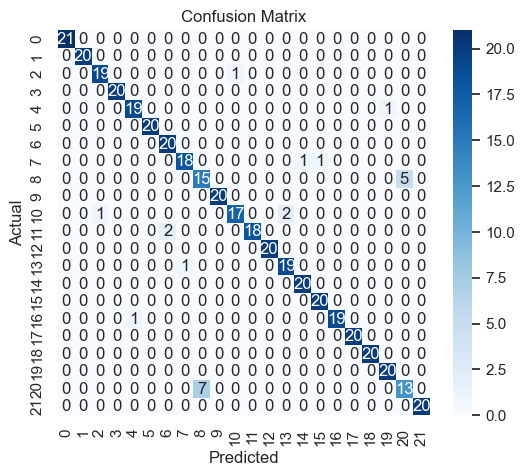

In [35]:
#CONFUSION MATRIX
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show() 

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Probability predictions
y_prob_dt = dt_model.predict_proba(X_test_scaled)

# Results
print("Decision Tree Results")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt,average='weighted',zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dt,average='weighted',zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_dt,average='weighted',zero_division=0))

print("\nClassification Report")
print(classification_report(y_test,y_pred_dt,zero_division=0))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_dt,multi_class='ovr',average='weighted'))

Decision Tree Results
Accuracy : 0.9841269841269841
Precision: 0.9845475366420587
Recall   : 0.9841269841269841
F1 Score : 0.9841139971343529

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20
           2       1.00      0.90      0.95        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.90      0.95      0.93        20
           9       1.00      1.00      1.00        20
          10       0.95      0.95      0.95        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.90      0.95      0.93        20
          14       1.00 

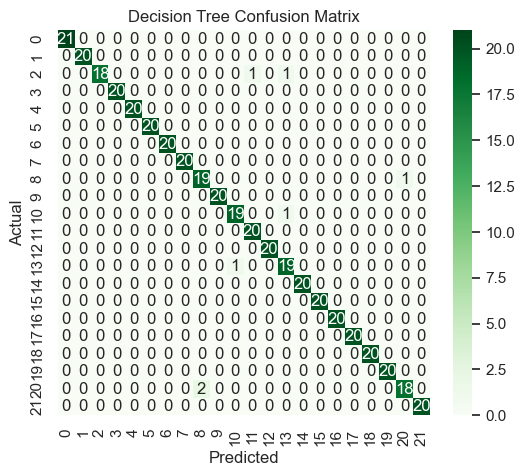

In [37]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)

rf_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Probability predictions
y_prob_rf = rf_model.predict_proba(X_test_scaled)

# Results
print("Random Forest Results")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf,average='weighted',zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf,average='weighted',zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_rf,average='weighted',zero_division=0))

print("\nClassification Report")
print(classification_report(y_test,y_pred_rf,zero_division=0))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_rf,multi_class='ovr',average='weighted'))

Random Forest Results
Accuracy : 0.9909297052154195
Precision: 0.9915579507416242
Recall   : 0.9909297052154195
F1 Score : 0.9909155026914582

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.91      1.00      0.95        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00 

In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score)

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=6,random_state=42,eval_metric='mlogloss')

xgb_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Probability predictions
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)

# Results
print("XGBoost Results") 

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb,average='weighted',zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_xgb,average='weighted',zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_xgb,average='weighted',zero_division=0))

print("\nClassification Report")
print(classification_report(y_test,y_pred_xgb,zero_division=0))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_xgb,multi_class='ovr',average='weighted'))

XGBoost Results
Accuracy : 0.9886621315192744
Precision: 0.9893983567452956
Recall   : 0.9886621315192744
F1 Score : 0.9885853078067063

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       0.95      1.00      0.98        20
          10       1.00      0.90      0.95        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       0.91      1.00      0.95        20
          14       1.00      1

In [40]:
print("Training Accuracy:", rf_model.score(X_train, y_train))
print("Testing Accuracy :", rf_model.score(X_test, y_test))

Training Accuracy: 0.045428733674048836
Testing Accuracy : 0.045351473922902494


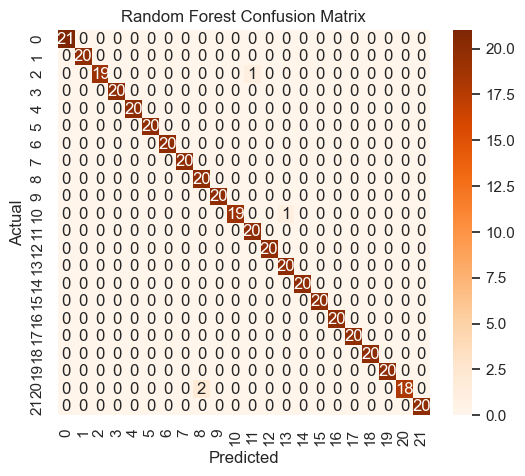

In [41]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score)

# Train SVM
svm_model = SVC(kernel='rbf',probability=True,random_state=42)

svm_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Probability predictions
y_prob_svm = svm_model.predict_proba(X_test_scaled)

# Results
print("SVM Results")

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm,average='weighted',zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_svm,average='weighted',zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_svm,average='weighted',zero_division=0))

print("\nClassification Report")
print(classification_report(y_test,y_pred_svm,zero_division=0))

print("\nROC-AUC:",roc_auc_score(y_test,y_prob_svm,multi_class='ovr',average='weighted'))

SVM Results
Accuracy : 0.981859410430839
Precision: 0.983587085627902
Recall   : 0.981859410430839
F1 Score : 0.9817649550518308

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.95      0.95      0.95        20
           7       1.00      1.00      1.00        20
           8       0.83      1.00      0.91        20
           9       0.95      1.00      0.98        20
          10       1.00      0.95      0.97        20
          11       0.95      0.95      0.95        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00      1.00    

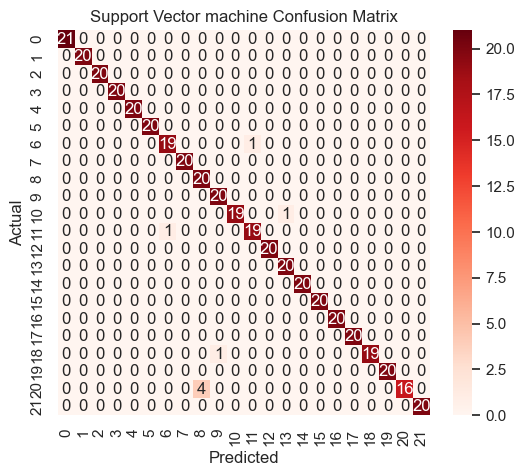

In [43]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds')

plt.title("Support Vector machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
from sklearn.naive_bayes import GaussianNB


# Train Naive Bayes
nb_model = GaussianNB()

nb_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_nb = nb_model.predict(X_test_scaled)

# Probability predictions
y_prob_nb = nb_model.predict_proba(X_test_scaled)

# Results
print("Naive Bayes Results")

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(
    y_test, y_pred_nb,
    average='weighted',
    zero_division=0
))
print("Recall   :", recall_score(
    y_test, y_pred_nb,
    average='weighted',
    zero_division=0
))
print("F1 Score :", f1_score(
    y_test, y_pred_nb,
    average='weighted',
    zero_division=0
))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))


print("\nROC-AUC:",
      roc_auc_score(
          y_test,
          y_prob_nb,
          multi_class='ovr',
          average='weighted'
      ))

Naive Bayes Results
Accuracy : 0.9931972789115646
Precision: 0.9937175447379529
Recall   : 0.9931972789115646
F1 Score : 0.9931844945074885

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.91      1.00      0.95        20
           9       1.00      1.00      1.00        20
          10       1.00      0.95      0.97        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       0.95      1.00      0.98        20
          14       1.00   

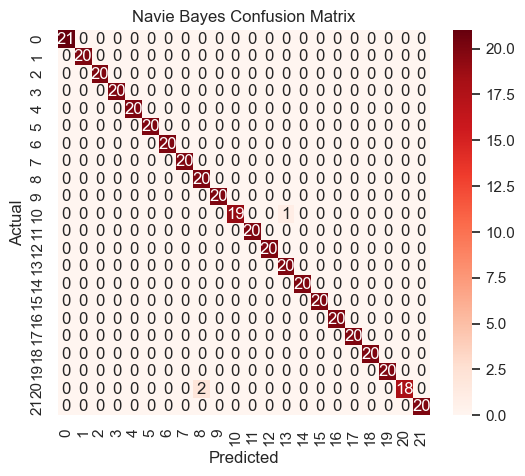

In [45]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds')

plt.title("Navie Bayes Confusion Matrix")
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.show() 

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Train KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Probability predictions
y_prob_knn = knn_model.predict_proba(X_test_scaled)

# Results
print("KNN Results")

print("Accuracy :", accuracy_score(y_test, y_pred_knn))

print("Precision:", precision_score(
    y_test,
    y_pred_knn,
    average='weighted',
    zero_division=0
))

print("Recall   :", recall_score(
    y_test,
    y_pred_knn,
    average='weighted',
    zero_division=0
))

print("F1 Score :", f1_score(
    y_test,
    y_pred_knn,
    average='weighted',
    zero_division=0
))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_knn,
    zero_division=0
))


print("\nROC-AUC:",
      roc_auc_score(
          y_test,
          y_prob_knn,
          multi_class='ovr',
          average='weighted'
      ))

KNN Results
Accuracy : 0.9773242630385488
Precision: 0.978587867378166
Recall   : 0.9773242630385488
F1 Score : 0.9772183982442227

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        20
           2       0.87      1.00      0.93        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00        20
           8       0.91      1.00      0.95        20
           9       0.95      1.00      0.98        20
          10       0.94      0.85      0.89        20
          11       1.00      0.95      0.97        20
          12       1.00      1.00      1.00        20
          13       0.90      0.90      0.90        20
          14       1.00      1.00  

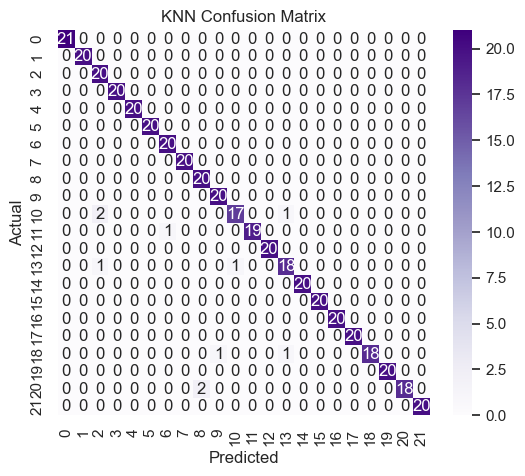

In [47]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Purples')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual") 
plt.show()


In [48]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_results = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb,
    "KNN": y_pred_knn
}

results = []

for model_name, y_pred in model_results.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])


comparison_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

comparison_df.iloc[:, 1:] = comparison_df.iloc[:, 1:].round(4)

comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

print(comparison_df)


                 Model  Accuracy  Precision  Recall  F1 Score
0          Naive Bayes    0.9932     0.9937  0.9932    0.9932
1        Random Forest    0.9909     0.9916  0.9909    0.9909
2              XGBoost    0.9887     0.9894  0.9887    0.9886
3        Decision Tree    0.9841     0.9845  0.9841    0.9841
4                  SVM    0.9819     0.9836  0.9819    0.9818
5                  KNN    0.9773     0.9786  0.9773    0.9772
6  Logistic Regression    0.9478     0.9486  0.9478    0.9476


In [49]:
import pandas as pd

from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier


In [50]:
lr = LogisticRegression(
    random_state=42,
    max_iter=3000
)

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

lr_grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(lr_grid.best_params_)

print("Best CV Accuracy:")
print(lr_grid.best_score_)

best_lr = lr_grid.best_estimator_

Best Parameters:
{'C': 100, 'class_weight': None, 'solver': 'lbfgs'}
Best CV Accuracy:
0.9775516948352374


In [51]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(dt_grid.best_params_)

print("Best CV Accuracy:")
print(dt_grid.best_score_)

best_dt = dt_grid.best_estimator_

Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Accuracy:
0.9842853995530797


In [52]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
} 

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 
)

rf_grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(rf_grid.best_params_)

print("Best CV Accuracy:")
print(rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy:
0.9955103389670474


In [59]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 
)

xgb_grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(xgb_grid.best_params_)

print("Best CV Accuracy:")
print(xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_ 

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV Accuracy:
0.992706071192522


In [54]:
svm = SVC(
    probability=True,
    random_state=42
)

svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(svm_grid.best_params_)

print("Best CV Accuracy:")
print(svm_grid.best_score_)

best_svm = svm_grid.best_estimator_

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy:
0.9887766342492054


In [55]:
nb = GaussianNB()

nb_params = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

nb_grid = GridSearchCV(
    estimator=nb,
    param_grid=nb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

nb_grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(nb_grid.best_params_)

print("Best CV Accuracy:")
print(nb_grid.best_score_)

best_nb = nb_grid.best_estimator_

Best Parameters:
{'var_smoothing': 1e-12}
Best CV Accuracy:
0.9882179838227426


In [56]:
knn = KNeighborsClassifier()

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=knn_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(knn_grid.best_params_)

print("Best CV Accuracy:")
print(knn_grid.best_score_)

best_knn = knn_grid.best_estimator_

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy:
0.9814858527680735


In [57]:
y_pred_lr_tuned = best_lr.predict(X_test_scaled)

y_pred_dt_tuned = best_dt.predict(X_test_scaled)

y_pred_rf_tuned = best_rf.predict(X_test_scaled)

y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

y_pred_svm_tuned = best_svm.predict(X_test_scaled)

y_pred_nb_tuned = best_nb.predict(X_test_scaled)

y_pred_knn_tuned = best_knn.predict(X_test_scaled)

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

tuned_models = {
    "Logistic Regression": y_pred_lr_tuned,
    "Decision Tree": y_pred_dt_tuned,
    "Random Forest": y_pred_rf_tuned,
    "XGBoost": y_pred_xgb_tuned,
    "SVM": y_pred_svm_tuned,
    "Naive Bayes": y_pred_nb_tuned,
    "KNN": y_pred_knn_tuned
}

results = []

for model_name, y_pred in tuned_models.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

tuned_comparison = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

tuned_comparison = tuned_comparison.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

tuned_comparison.iloc[:, 1:] = tuned_comparison.iloc[:, 1:].round(4)

print(tuned_comparison)

                 Model  Accuracy  Precision  Recall  F1 Score
0              XGBoost    0.9932     0.9937  0.9932    0.9932
1          Naive Bayes    0.9932     0.9937  0.9932    0.9932
2        Random Forest    0.9909     0.9916  0.9909    0.9909
3        Decision Tree    0.9841     0.9852  0.9841    0.9841
4                  SVM    0.9819     0.9836  0.9819    0.9820
5                  KNN    0.9773     0.9777  0.9773    0.9773
6  Logistic Regression    0.9637     0.9642  0.9637    0.9636


In [60]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Stratified 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_xgb,
    X_train_resampled,
    y_train_resampled,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("XGBoost Cross-Validation Results")
print("----------------------------------")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Mean CV Accuracy (%): {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std():.4f}")

XGBoost Cross-Validation Results
----------------------------------
Fold 1 Accuracy: 0.9888
Fold 2 Accuracy: 0.9860
Fold 3 Accuracy: 0.9972
Fold 4 Accuracy: 0.9944
Fold 5 Accuracy: 0.9944

Mean CV Accuracy: 0.9921
Mean CV Accuracy (%): 99.21%
Standard Deviation: 0.0041


In [61]:
# Train final XGBoost model
final_xgb = best_xgb

final_xgb.fit(
    X_train_resampled,
    y_train_resampled
)

print("Final XGBoost model trained successfully!")

Final XGBoost model trained successfully!


In [64]:
import joblib  

joblib.dump(best_rf, "xg_boost_model.pkl")

print("XG Boost model saved successfully.")  

XG Boost model saved successfully.


In [65]:
#Verify the model
loaded_model = joblib.load("xg_boost_model.pkl")
         
print(type(loaded_model)) 

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [67]:
import numpy as np

# Random test input
test_input = np.array([[
    90,      # Nitrogen
    42,      # Phosphorous
    43,      # Potassium
    20.8,    # Temperature
    82.0,    # Humidity
    6.5,     # pH
    202.9    # Rainfall
]])

# Scale the input
test_input_scaled = scaler.transform(test_input)

# Predict
prediction = final_xgb.predict(test_input_scaled)

# Convert encoded prediction back to crop name
predicted_crop = label_encoders['crop'].inverse_transform(prediction)

print("Predicted Crop:", predicted_crop[0])


Predicted Crop: rice
